# Result 2 — Biodiversity-loss evidence differs systematically across national income groups

**Question:** where does the country-linked biodiversity-loss evidence sit geographically,
does its documented-threat composition differ with the income group of the country a study
is about, and does any difference survive holding region and publication period constant?


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis import driver_composition
from data_helpers.analysis.geo.geography import SHAPEFILE_PATH, load_polygons
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
DRIVER_CONFIG = RESULTS_CONFIG["driver_composition"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]
THREAT_ORDER, THREAT_COLORS, THREAT_DISPLAY_NAMES = results_config.threat_l0_display(
    RESULTS_CONFIG
)

INCOME_GROUPS = INCOME_CONFIG["group_order"]
TIER_ORDER = INCOME_CONFIG["tier_order"]
LOWER_TIER = set(INCOME_CONFIG["tiers"]["Lower-income tier"])
PERIOD_BINS, PERIOD_LABELS = driver_composition.publication_period_bins(
    DRIVER_CONFIG["publication_periods"]
)

MAPPING_PATH = PROJECT_ROOT / INCOME_CONFIG["world_bank_mapping"]
HISTORICAL_PATH = (
    PROJECT_ROOT
    / INCOME_CONFIG["world_bank_snapshot_curated"]
    / DRIVER_CONFIG["historical_classifications_file"]
)

# One output section holds this result: derived data, manuscript tables, figure.
OUTPUT_DIR = PROJECT_ROOT / DRIVER_CONFIG["output_directory"]
DATA_DIR = OUTPUT_DIR / DRIVER_CONFIG["data_subdirectory"]
TABLE_DIR = OUTPUT_DIR / DRIVER_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / DRIVER_CONFIG["figure_subdirectory"]
for directory in (DATA_DIR, TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

# Provenance: the complete set of inputs this result depends on.
print("Inputs")
for label, path in (
    ("evidence corpus  ", CORPUS_DIR),
    ("country mapping  ", MAPPING_PATH),
    ("income snapshot  ", HISTORICAL_PATH),
    ("country polygons  ", SHAPEFILE_PATH),
):
    status = "found" if path.exists() else "MISSING"
    print(f"  {label} {path.relative_to(PROJECT_ROOT)}  [{status}]")
missing = [
    path
    for path in (CORPUS_DIR, MAPPING_PATH, HISTORICAL_PATH, SHAPEFILE_PATH)
    if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Run the data-processing prep notebooks first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Inputs
  evidence corpus   notebooks/data_processing/outputs/04_biodiversity_evidence_corpus_prep  [found]
  country mapping   checklists/mappings/ipbes_world_bank_mapping.json  [found]
  income snapshot   data/world-bank/snapshots/wdi-2026-06-30/curated/classifications_historical.parquet  [found]
  country polygons   data/ipbes-polygons/ipbes_regions_subregions_shape_1.1/IPBES_Regions_Subregions2.shp  [found]

Output section: notebooks/results/outputs/02_income_composition


## 1. Evidence and historical income matching

Retain negative-direction records from all study designs, expand them to unique
publication–country assignments, and attach the official World Bank classification in
force in the publication year rather than the current one, because a country's group
can change over the study period. All three panels use the same country-linked, standard
historical-income subset from complete publication years 2000–2025. The observational
records are retained only as a sensitivity comparison.

The audit table below carries the manuscript's article and country counts, and the
reclassified share reported in the Supplementary "Historical income matching" paragraph.

In [5]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(
    CORPUS_DIR
).load(columns=["UT", "publication_year", "s2_dir", "pred_study_design", "pred_countries", "pred_threat_l0"]).publications

evidence_preparation = driver_composition.prepare_historical_income_evidence(
    corpus_df,
    mapping_path=MAPPING_PATH,
    historical_path=HISTORICAL_PATH,
    income_groups=INCOME_GROUPS,
    direction=DRIVER_CONFIG["direction"],
    sensitivity_study_design=DRIVER_CONFIG["sensitivity_study_design"],
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
)
linked_country_df = evidence_preparation.primary
country_counts = driver_composition.build_country_article_counts(linked_country_df)
figure_publication_count = linked_country_df["UT"].nunique()
assert country_counts.shape[0] == 213
country_polygons = load_polygons(
    simplify_tolerance=0.2, preserve_topology=True
)
assert set(country_counts["iso3"]).issubset(
    set(country_polygons["ISO_3"].dropna())
)

display(
    evidence_preparation.audit.style.format({"value": "{:,}"}).hide(axis="index")
)
print(f"Reclassified share: {evidence_preparation.reclassified_share:.1%}")
print(
    f"All panels use {figure_publication_count:,} country-resolved biodiversity-loss "
    f"publications ({DRIVER_CONFIG['primary_start_year']}–"
    f"{DRIVER_CONFIG['primary_end_year']}, all study designs)."
)

metric,value
Negative publications (all study designs),"253,081"
Negative observational publications,"116,684"
All-design World Bank-linked publication–country assignments,"171,595"
All-design World Bank-linked unique publications,"151,541"
"All-design primary assignments: historical group, 2000–2025","166,282"
All-design primary unique publications,"146,892"
Countries in all-design primary analysis,213
Assignments reclassified vs current group,"17,709"


Reclassified share: 10.6%
All panels use 146,892 country-resolved biodiversity-loss publications (2000–2025, all study designs).


## 2. Geographic coverage, threat composition, and the extreme-group contrast

Panel **a** maps the shared 146,892-publication all-design subset. Panel **b** gives the
same publications' within-income-group composition and shows each group count beneath its
abbreviated label.
Panel **c** gives the HIC-minus-LIC difference in each category's share, in percentage
points, with 95% bootstrap intervals. The ten contrasted layers in panel b follow panel
c's signed order from bottom to top; `Other threats` and `Unclear` form the residual block
at the top.

This is Figure `income_composition` in the manuscript, and the six rows printed below are
the contrasts quoted in the main text.

,unique_publications,represented_countries
historical_income_group,,
Low income,"6,986",70
Lower middle income,"23,659",101
Upper middle income,"48,284",90
High income,"73,385",85


,threat,low_income_share_pct,high_income_share_pct,high_minus_low_pp,bootstrap_ci_low,bootstrap_ci_high
11,Agriculture & Aquaculture,24.23,8.55,-15.68,-16.61,-14.79
10,Biological Resource Use,18.78,8.62,-10.16,-10.95,-9.29
0,Pollution,14.55,24.31,9.75,8.95,10.53
1,"Invasive & Other Problematic Species, Genes & ...",8.63,17.07,8.45,7.80,9.08
2,Climate Change & Severe Weather,11.40,17.33,5.93,5.18,6.63
3,Natural System Modifications,6.73,9.97,3.24,2.73,3.75


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/02_income_composition/figures/income_composition.pdf


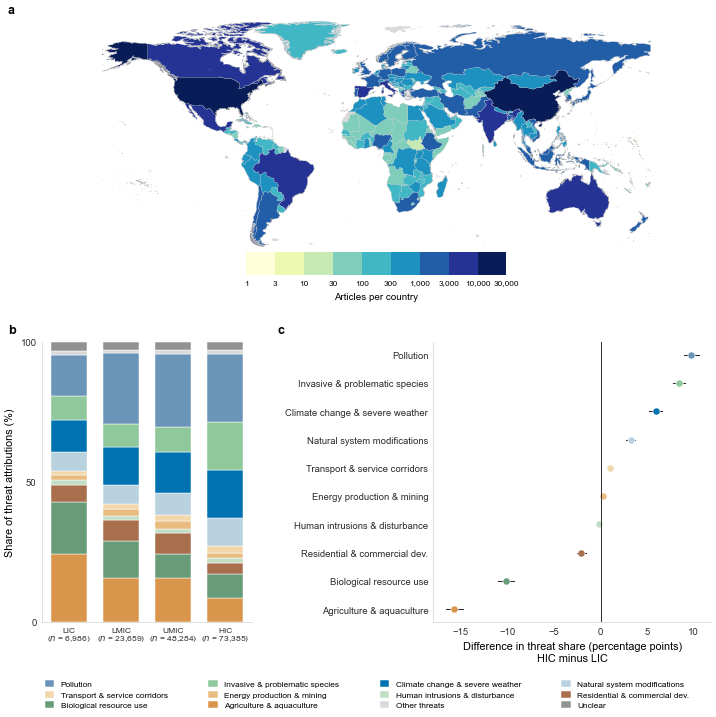

In [6]:
composition_analysis = driver_composition.analyze_income_composition(
    linked_country_df,
    threat_order=THREAT_ORDER,
    income_groups=INCOME_GROUPS,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"],
)
observed_threat_order = composition_analysis.observed_threat_order

display(composition_analysis.group_counts.style.format("{:,}"))
display(
    composition_analysis.extreme_contrast.assign(
        absolute_difference=lambda df: df["high_minus_low_pp"].abs()
    )
    .nlargest(6, "absolute_difference")[
        [
            "threat",
            "low_income_share_pct",
            "high_income_share_pct",
            "high_minus_low_pp",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
        ]
    ]
    .round(2)
)

composition_figure = driver_composition.plot_income_composition(
    composition_analysis,
    income_groups=INCOME_GROUPS,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_DISPLAY_NAMES,
    country_counts=country_counts,
    polygons=country_polygons,
    contrast_excluded_threats=DRIVER_CONFIG["contrast_plot_excluded_threats"],
)
visualization.save_figure(
    composition_figure,
    FIGURE_DIR / DRIVER_CONFIG["composition_figure_filename"],
    formats=["pdf"],
    dpi=300,
    pad_inches=0.05,
)
plt.show()

## 3. Hold region and publication period constant

Income groups differ in which world regions and publication periods they draw on, so a
raw contrast could reflect the geography and timing of research rather than income. Pool
low and lower-middle into a lower-income tier and upper-middle and high into a
higher-income tier, then directly standardize both tiers to the same World Bank region ×
five-year-period distribution, using only strata present in both tiers. This is
descriptive adjustment, not a causal model, and pooling attenuates the contrast relative
to the extreme-group comparison in section 2.

The table below is Supplementary Table `income_standardized`.

In [7]:
standardization_analysis = driver_composition.analyze_standardized_tiers(
    linked_country_df,
    lower_tier_groups=LOWER_TIER,
    period_bins=PERIOD_BINS,
    period_labels=PERIOD_LABELS,
    threat_order=observed_threat_order,
    tier_order=TIER_ORDER,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"] + 1,
)
standardization_meta = standardization_analysis.metadata

print(
    f"Shared regions: {standardization_meta['common_regions']}; "
    "shared region × period strata: "
    f"{standardization_meta['common_region_period_strata']}"
)
display(
    standardization_analysis.contrasts.loc[
        standardization_analysis.contrasts["threat"].isin(
            DRIVER_CONFIG["focus_threats"]
        ),
        [
            "threat",
            "raw_higher_minus_lower_pp",
            "region_standardized_higher_minus_lower_pp",
            "region_period_standardized_higher_minus_lower_pp",
            "joint_bootstrap_ci_low",
            "joint_bootstrap_ci_high",
        ],
    ].round(2)
)

Shared regions: 6; shared region × period strata: 28


,threat,raw_higher_minus_lower_pp,region_standardized_higher_minus_lower_pp,region_period_standardized_higher_minus_lower_pp,joint_bootstrap_ci_low,joint_bootstrap_ci_high
0,"Invasive & Other Problematic Species, Genes & ...",5.76,4.74,5.01,4.34,5.64
1,Pollution,1.88,0.68,2.83,1.70,3.88
2,Climate Change & Severe Weather,3.06,4.38,2.24,1.07,3.26
5,Natural System Modifications,2.44,-0.04,0.30,-0.35,0.86
10,Biological Resource Use,-5.70,-4.77,-4.24,-4.97,-3.53
11,Agriculture & Aquaculture,-6.40,-6.70,-7.56,-8.38,-6.67


## 4. Robustness of the contrast

Recalculate the extreme-group contrast under five alternative specifications:
observational studies only, current rather than historical
income classification, a shifted fiscal-year boundary, the partial 2026 year included,
and country-fractional weighting. Rank correlation and direction agreement near one mean
the reported pattern does not depend on these choices.

This is the Supplementary "Sensitivity analyses" paragraph.

In [8]:
sensitivity_df = driver_composition.build_sensitivity_summary(
    evidence_preparation,
    composition_analysis,
    income_groups=INCOME_GROUPS,
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
    partial_end_year=DRIVER_CONFIG["partial_end_year"],
)
display(sensitivity_df.round(3))

,comparison,rank_correlation,largest_change_pp,direction_agreement
0,Observational study design only,0.993,2.053,1.000
1,Current income classification,0.993,5.010,0.917
2,FY = publication year + 1,1.000,0.564,1.000
3,Include partial 2026,1.000,0.120,1.000
4,Country-fractional weighting,0.993,0.839,1.000


## 5. Export

The derived data and manuscript tables for this result: the classified assignments and
threat attributions as Parquet, then the classification audit, per-country and per-group
article counts, within-group composition,
extreme-group bootstrap contrast, region–period
standardized tier contrast, and sensitivity summary as CSV.

In [9]:
assert linked_country_df["UT"].nunique() == 146_892
assert figure_publication_count == 146_892
assert country_counts.shape[0] == 213
assert country_counts["record_count"].sum() == 166_282
assert composition_analysis.group_counts["unique_publications"].tolist() == [
    6_986, 23_659, 48_284, 73_385
]
assert country_counts["record_count"].max() == 25_689
assert set(country_counts["iso3"]).issubset(
    set(country_polygons["ISO_3"].dropna())
)

In [10]:
written_paths = driver_composition.export_manuscript_tables(
    evidence_preparation,
    composition_analysis,
    standardization_analysis,
    sensitivity_df,
    country_counts=country_counts,
    data_directory=DATA_DIR,
    table_directory=TABLE_DIR,
    classified_assignments_file=DRIVER_CONFIG["classified_assignments_file"],
    threat_attributions_file=DRIVER_CONFIG["threat_attributions_file"],
)
figure_paths = sorted(FIGURE_DIR.glob("*.pdf"))
for path in [*written_paths, *figure_paths]:
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/02_income_composition/data/historical_income_publication_country_assignments.parquet
notebooks/results/outputs/02_income_composition/data/historical_income_threat_attributions.parquet
notebooks/results/outputs/02_income_composition/csv/historical_income_classification_audit.csv
notebooks/results/outputs/02_income_composition/csv/income_group_article_counts.csv
notebooks/results/outputs/02_income_composition/csv/income_group_threat_composition.csv
notebooks/results/outputs/02_income_composition/csv/high_minus_low_income_bootstrap.csv
notebooks/results/outputs/02_income_composition/csv/region_period_standardized_tier_contrast.csv
notebooks/results/outputs/02_income_composition/csv/sensitivity_summary.csv
notebooks/results/outputs/02_income_composition/csv/country_article_counts.csv
notebooks/results/outputs/02_income_composition/figures/income_composition.pdf
